In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **PART I**

To start with this seminar we first load the dataset that contains features (CSI matrices) and labels (human poses), which are
split into train and test partitions.

In [ ]:
import pandas as pd

# Define the base path
base_path = '/content/drive/MyDrive/AAX/seminar 2/dataset_Seminar2/'

# Load training data with header=None
X_train = pd.read_csv(base_path + 'Train_features.csv', header=None)
train_skeleton = pd.read_csv(base_path + 'Train_skelletonpoints.csv', header=None)
# Load labels, header=None, and transpose (.T) to turn the row into a column
y_train = pd.read_csv(base_path + 'Train_labels.csv', header=None).T

# Load testing data with header=None
X_test = pd.read_csv(base_path + 'Test_features.csv', header=None)
test_skeleton = pd.read_csv(base_path + 'Test_skelletonpoints.csv', header=None)
y_test = pd.read_csv(base_path + 'Test_labels.csv', header=None).T

print("Data loaded correctly!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("train_skeleton shape:", train_skeleton.shape)

Data loaded correctly!
X_train shape: (1000, 270)
y_train shape: (1000, 1)
train_skeleton shape: (1000, 54)


Next, we create a function that takes SkelletonPoints as input and plots the corresponding pose

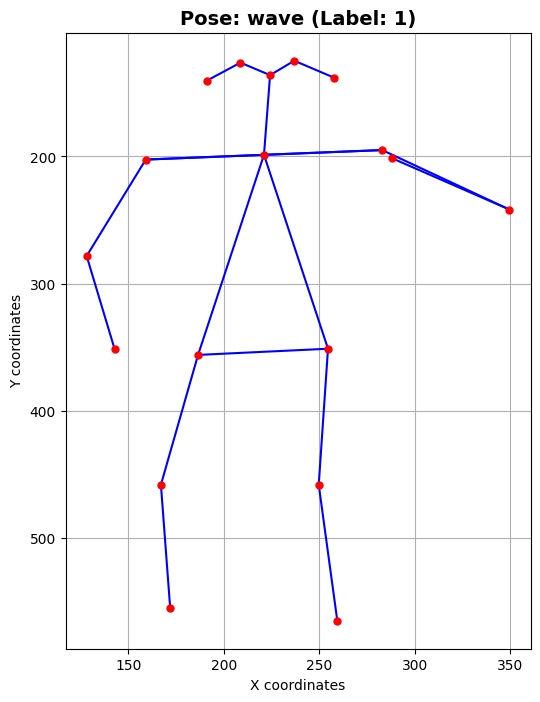

In [ ]:
import matplotlib.pyplot as plt

# Mapping numerical labels to actual pose names based on Slide 5
pose_mapping = {1: 'wave', 2: 'push', 3: 'crouch', 4: 'sitdown', 5: 'bend'}

def plot_skeleton_with_bones(sample_index):
    # SWAPPED: First 18 are actually Y, next 18 are actually X
    y_coords = train_skeleton.iloc[sample_index, 0:18].values
    x_coords = train_skeleton.iloc[sample_index, 18:36].values

    # Get the label and map it to the string name
    num_label = y_train.iloc[sample_index, 0]
    pose_name = pose_mapping.get(num_label, "Unknown")

    # Connections from Slides
    connections = [
        (0, 1),   # Nose - Neck
        (1, 2),   # Neck - Right Shoulder
        (2, 3),   # Right Shoulder - Right Elbow
        (3, 4),   # Right Elbow - Right Wrist
        (1, 5),   # Neck - Left Shoulder
        (5, 6),   # Left Shoulder - Left Elbow
        (6, 7),   # Left Elbow - Left Wrist
        (1, 8),   # Neck - Right Hip
        (8, 9),   # Right Hip - Right Knee
        (9, 10),  # Right Knee - Right Ankle
        (1, 11),  # Neck - Left Hip
        (11, 12), # Left Hip - Left Knee
        (12, 13), # Left Knee - Left Ankle
        (0, 14),  # Nose - Right Eye
        (0, 15),  # Nose - Left Eye
        (14, 16), # Right Eye - Right Ear
        (15, 17), # Left Eye - Left Ear
        (2, 5),   # Right Shoulder - Left Shoulder
        (8, 11)   # Right Hip - Left Hip
    ]

    plt.figure(figsize=(6, 8))

    # Draw the bones (lines) by looping through the connections
    for start, end in connections:
        plt.plot([x_coords[start], x_coords[end]], [y_coords[start], y_coords[end]], 'b-', linewidth=1.5)

    # Draw the joints (red dots)
    plt.plot(x_coords, y_coords, 'ro', markersize=5)

    plt.title(f'Pose: {pose_name} (Label: {num_label})', fontsize=14, fontweight='bold')
    plt.xlabel('X coordinates')
    plt.ylabel('Y coordinates')

    # We need this so the head (lower Y values) stays at the top
    plt.gca().invert_yaxis()

    plt.grid(True)
    plt.show()

# Test the function!
plot_skeleton_with_bones(0)

In this plot we can see how the corresponding pose is plotted with its label which in this case is wave.

Then, we implement the code for plotting the average CSI amplitude per subcarrier.

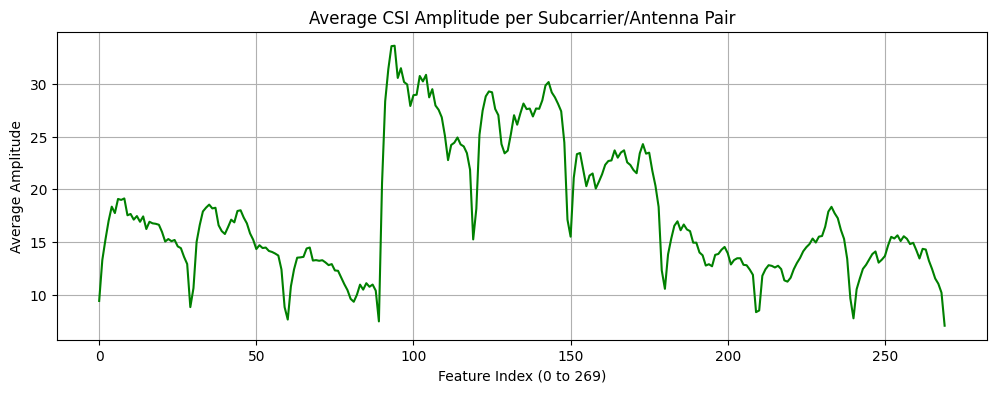

In [ ]:
import matplotlib.pyplot as plt

# Calculate the mean across all 1000 samples for each of the 270 features (subcarriers/antennas)
avg_csi = X_train.mean(axis=0)

plt.figure(figsize=(12, 4))
plt.plot(avg_csi.values, color='green', linewidth=1.5)
plt.title('Average CSI Amplitude per Subcarrier/Antenna Pair')
plt.xlabel('Feature Index (0 to 269)')
plt.ylabel('Average Amplitude')
plt.grid(True)
plt.show()

This plot shows the raw frequency response of your Wi-Fi environment without separating it by human actions. We can notice peaks and valleys along the green line. The valleys show subcarriers where the signal naturally cancels out or gets heavily attenuated due to the room's layout (multipath fading), while the peaks show frequencies that transmit with high efficiency.

To continue we plot the distribution of the CSI amplitude across each subcarrier for each class.

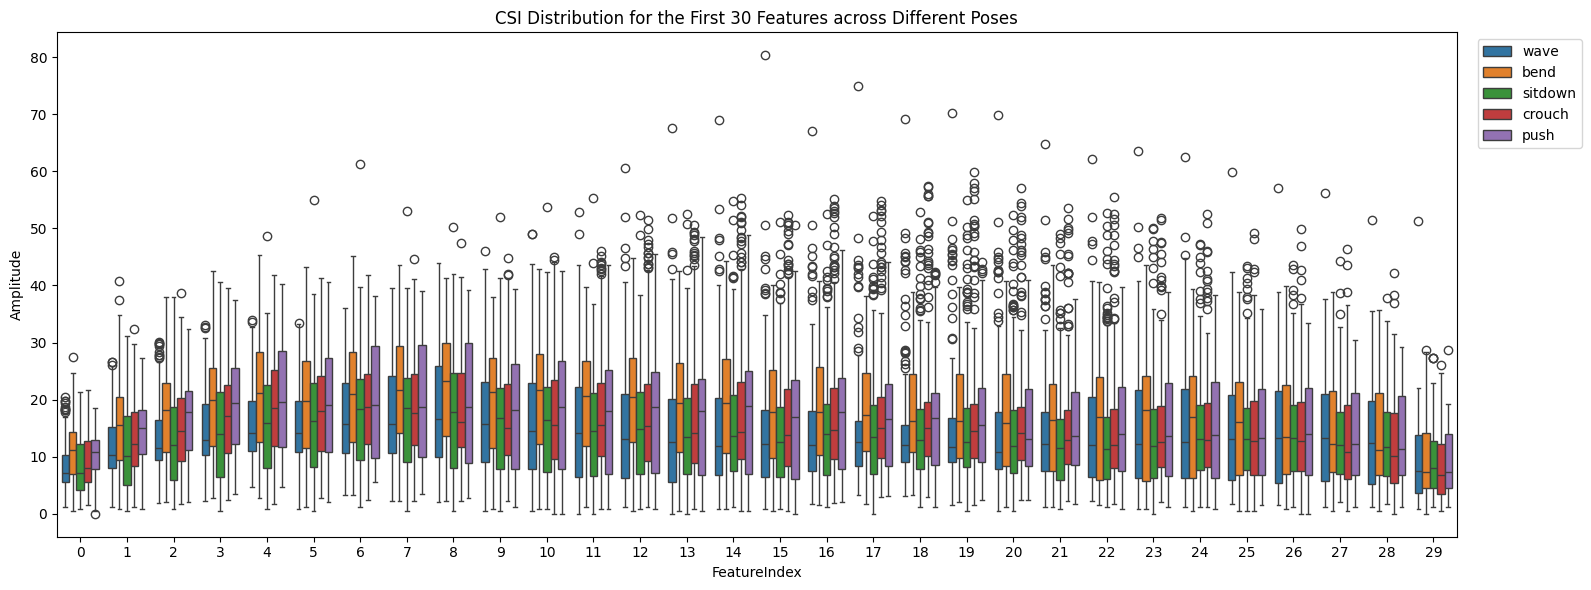

In [ ]:
import seaborn as sns
import pandas as pd

# Combine features and labels into one dataframe for seaborn plotting
df_combined = X_train.copy()
df_combined['PoseLabel'] = y_train.values

# Map the numerical labels to the pose names (from Slide 5)
pose_mapping = {1: 'wave', 2: 'push', 3: 'crouch', 4: 'sitdown', 5: 'bend'}
df_combined['PoseName'] = df_combined['PoseLabel'].map(pose_mapping)

# 'Melt' the dataframe to make it suitable for a boxplot
df_melted = df_combined.melt(id_vars=['PoseName', 'PoseLabel'], var_name='FeatureIndex', value_name='Amplitude')

# Filter to only show the first 30 features so the plot is readable
subset_df = df_melted[df_melted['FeatureIndex'] < 30]

plt.figure(figsize=(16, 6))
sns.boxplot(data=subset_df, x='FeatureIndex', y='Amplitude', hue='PoseName')
plt.title('CSI Distribution for the First 30 Features across Different Poses')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In this plot we can see the statistical distribution (the median, quartiles, spread, and potential outliers) of the CSI amplitudes for the first $30$ feature channels, broken down by the five specific physical actions (wave, push, crouch, sitdown, bend).

This is a feature discriminability analysis. For a machine learning classifier to accurately recognize a pose, the wireless signal must change in a unique, identifiable way for each action.

# **PART II**


After the data to be used is clear, now is the time to implement the classifier based on SVM, so that we can guess the pose of someone simply by analyzing Wi-Fi signals. To start with, we create a module that loads the training data and fits it into an SVM, to do this we used sklearn librarie that implement SVMs.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Initializing and training the SVM Model...")
# Initialize the SVM. We use 'rbf' (Radial Basis Function) as it generally performs very well on complex/non-linear signals like Wi-Fi CSI data.
svm_model = SVC(kernel='rbf', random_state=42)

# Fit the model using X_train (features) and y_train (labels)
# We use .values.ravel() to flatten the labels into a 1D array
svm_model.fit(X_train, y_train.values.ravel())

print("Model training complete!")

# Generate predictions on the unseen Test dataset
print("Generating predictions on the test dataset...")
y_pred = svm_model.predict(X_test)

Initializing and training the SVM Model...
Model training complete!
Generating predictions on the test dataset...


At last, we evaluate the SVM with the overall accuracy, a classification report and a confusion matrix.


--- Evaluation Metrics ---
Overall Accuracy: 66.00%

Classification Report:
              precision    recall  f1-score   support

        wave       0.72      0.69      0.71        42
        push       0.55      0.79      0.65        39
      crouch       0.65      0.74      0.69        35
     sitdown       0.73      0.42      0.53        38
        bend       0.71      0.65      0.68        46

    accuracy                           0.66       200
   macro avg       0.67      0.66      0.65       200
weighted avg       0.68      0.66      0.66       200



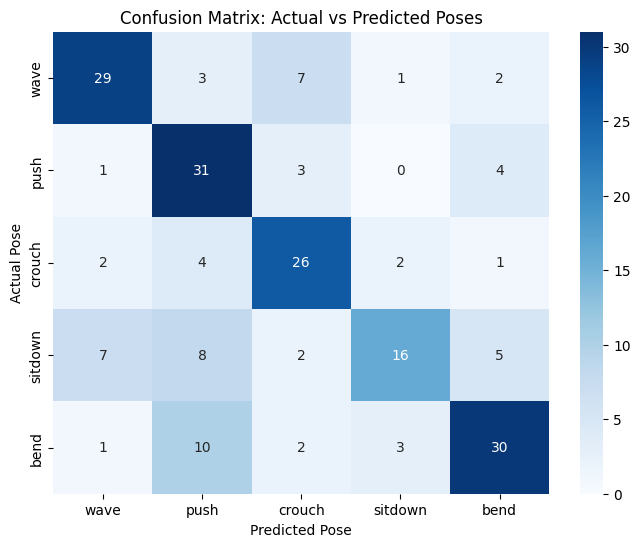

In [ ]:
# 1. Calculate Overall Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Evaluation Metrics ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# 2. Detailed Classification Report
# We map the labels to pose names for a cleaner output
pose_names = [pose_mapping[i] for i in sorted(pose_mapping.keys())]
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=pose_names))

# 3. Confusion Matrix Plot
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=pose_names,
            yticklabels=pose_names)
plt.title('Confusion Matrix: Actual vs Predicted Poses')
plt.xlabel('Predicted Pose')
plt.ylabel('Actual Pose')
plt.show()

After evaluating the SVM we get the following evaluation metrics results:

1. Overall Accuracy (66.00%): This tolds us that out of the $200$ total human action samples in your test dataset, your SVM correctly guessed the exact pose $132$ times ($200 \times 0.66$).

2. Classification Report: This have different metrics for the different poses:
    *   Precision (Quality of Positive Guesses): If we have high precision means we have low false alarms.
    *   Recall (Sensitivity / Detection Rate):  High recall means few missed events.
    *   F1-Score: The harmonic mean of Precision and Recall. It gives a single balance score out of $1.00$ for that class.

3. Confusion Matrix: This metric shows us exactly where the samples went. We can see that the diagonal blocks contain the successes.

In conclusion, we can say that the SVM works decently, but Wi-Fi CSI signals are highly vulnerable to spatial similarities. Poses like sitdown are heavily under-classified because their signal patterns overlap heavily with other spatial motions like push or crouch.

